In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

sys.path.append(os.path.abspath(os.path.join('..')))
from constants import MIBI_GUT_DIR_PATH

In [3]:
# Load the data
cell_df = pd.read_csv('../' + MIBI_GUT_DIR_PATH + 'cell_table.csv')
print(f'Total cells: {len(cell_df):,}')

Total cells: 713,372


In [4]:
print(cell_df.columns)
print(f"Unique cell types: {cell_df['cell type'].unique()}")

Index(['fov', 'cell_ID', 'cell type', 'population', 'in_CryptVilli',
       'in_BrunnerGland', 'in_SMV', 'in_Muscle', 'in_LP', 'in_Submucosa',
       'in_Follicle', 'in_Lumen', 'CD103', 'CD14', 'CD15', 'CD163', 'CD20',
       'CD206', 'CD209', 'CD3', 'CD31', 'CD38', 'CD4', 'CD45', 'CD45RA',
       'CD45RO', 'CD56', 'CD68', 'CD69', 'CD8', 'CHGA', 'Calprotectin',
       'Collagen', 'ECAD', 'FOXP3', 'GZMB', 'HLA1', 'HLADRDPDQ', 'IDO1', 'IgA',
       'Keratin', 'Ki67', 'Lysozyme', 'Mucin', 'NAKATPASE', 'PD1', 'PDL1',
       'SMA', 'TCF', 'Tryptase', 'VIM', 'dsDNA', 'Area', 'centroid_x',
       'centroid_y'],
      dtype='str')


Unique cell types: <StringArray>
[            'Goblet',               'CD4T',               'CD3T',
             'Muscle',         'Macrophage', 'ImmuneOther_CD45RA',
         'Fibroblast',               'CD8T',                'SMV',
             'Neuron',        'Endothelial',         'Epithelial',
              'Bcell',             'Plasma',       'Unidentified',
                'APC',        'ImmuneOther',                 'NK',
           'Monocyte',    'Macrophage_Calp',        'Plasma_CD38',
    'Mesenchymal_VIM',               'Mast',               'Treg',
             'Paneth',                 'DC',         'Neutrophil',
          'Endocrine',    'Neutrophil_CD15',     'Neuroendocrine',
       'BrunnerGland', 'FibroticEpithelial']
Length: 32, dtype: str


In [3]:
# Define the markers we want to investigate for subtyping
markers_of_interest = ['PD1', 'Ki67', 'CD103', 'CD163', 'CD45RA', 'CD45RO']

# Convert columns to float
for marker in markers_of_interest:
    cell_df[marker] = cell_df[marker].astype(float)

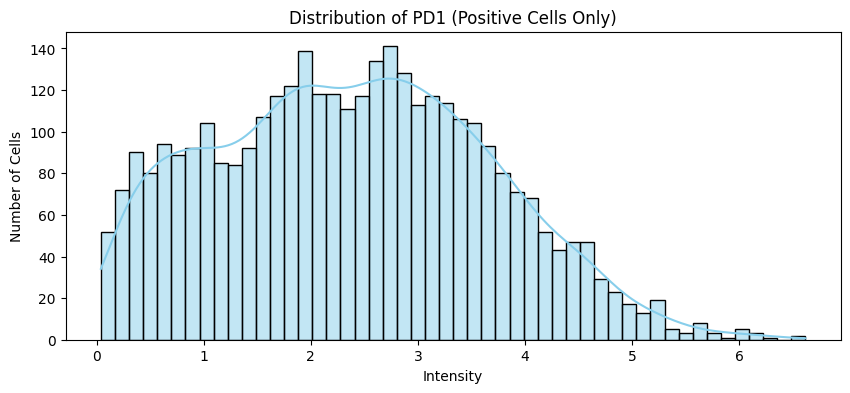

PD1 Summary Stats (All Cells):
count    713372.000000
mean          0.011593
std           0.188043
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           6.618656
Name: PD1, dtype: float64

PD1 Summary Stats (Positive Cells Only):
count    3473.000000
mean        2.381262
std         1.273097
min         0.039704
25%         1.389453
50%         2.366021
75%         3.292670
max         6.618656
Name: PD1, dtype: float64
--------------------------------------------------


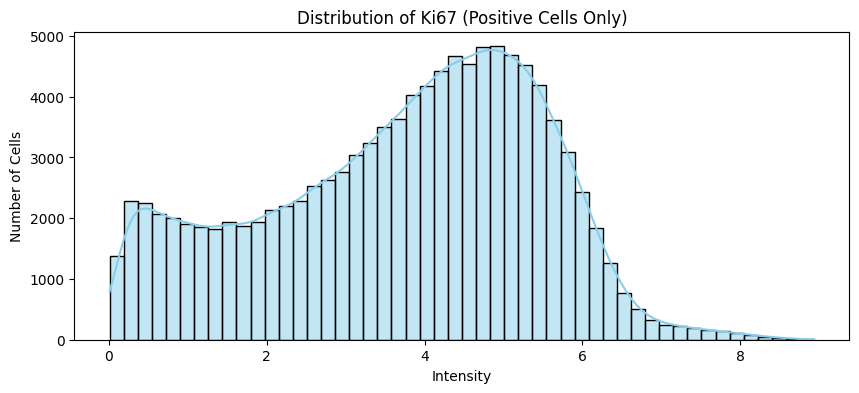

Ki67 Summary Stats (All Cells):
count    713372.000000
mean          0.568629
std           1.500913
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           8.936523
Name: Ki67, dtype: float64

Ki67 Summary Stats (Positive Cells Only):
count    109277.000000
mean          3.712072
std           1.742828
min           0.008508
25%           2.465030
50%           3.997013
75%           5.053343
max           8.936523
Name: Ki67, dtype: float64
--------------------------------------------------


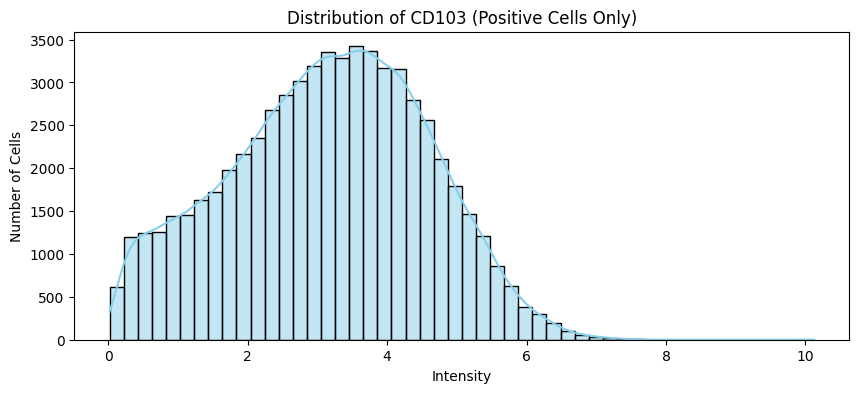

CD103 Summary Stats (All Cells):
count    713372.000000
mean          0.277817
std           0.986874
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          10.125989
Name: CD103, dtype: float64

CD103 Summary Stats (Positive Cells Only):
count    63093.000000
mean         3.141187
std          1.420368
min          0.019036
25%          2.129871
50%          3.214261
75%          4.182081
max         10.125989
Name: CD103, dtype: float64
--------------------------------------------------


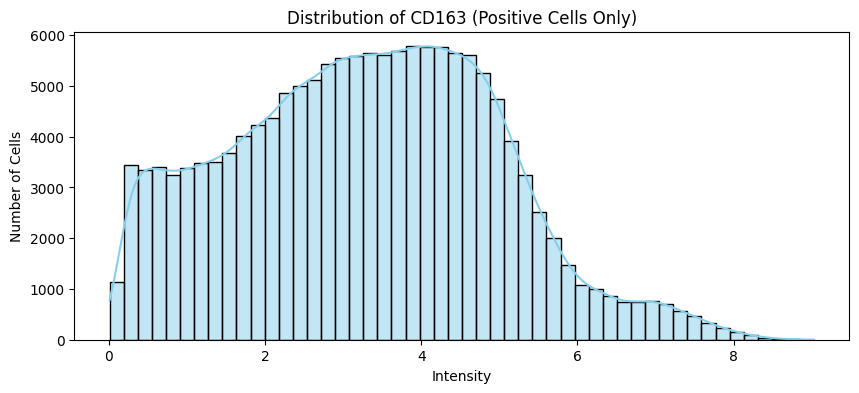

CD163 Summary Stats (All Cells):
count    713372.000000
mean          0.687618
std           1.542000
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           9.030263
Name: CD163, dtype: float64

CD163 Summary Stats (Positive Cells Only):
count    149362.000000
mean          3.284153
std           1.681988
min           0.010618
25%           2.013103
50%           3.317133
75%           4.495528
max           9.030263
Name: CD163, dtype: float64
--------------------------------------------------


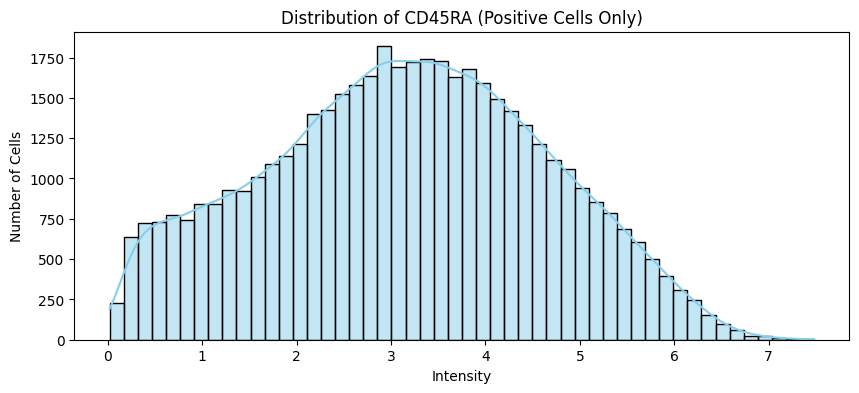

CD45RA Summary Stats (All Cells):
count    713372.000000
mean          0.204290
std           0.862011
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           7.483539
Name: CD45RA, dtype: float64

CD45RA Summary Stats (Positive Cells Only):
count    46326.000000
mean         3.145854
std          1.479424
min          0.017463
25%          2.080709
50%          3.175396
75%          4.223224
max          7.483539
Name: CD45RA, dtype: float64
--------------------------------------------------


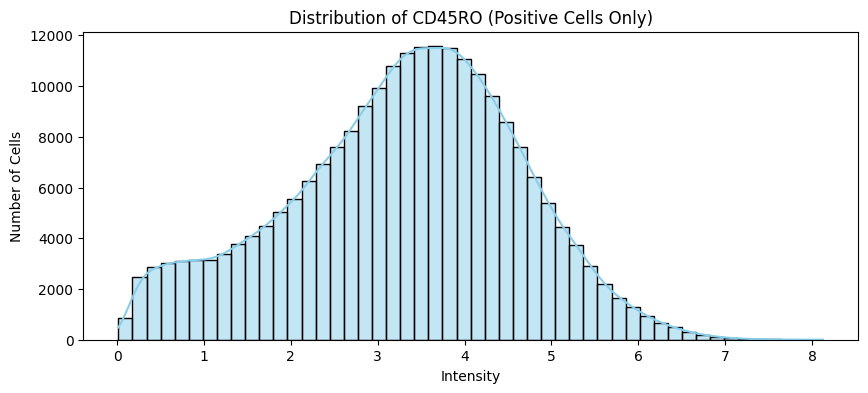

CD45RO Summary Stats (All Cells):
count    713372.000000
mean          1.050145
std           1.709682
min           0.000000
25%           0.000000
50%           0.000000
75%           2.247327
max           8.125176
Name: CD45RO, dtype: float64

CD45RO Summary Stats (Positive Cells Only):
count    227874.000000
mean          3.287536
std           1.339831
min           0.014905
25%           2.422808
50%           3.404919
75%           4.226947
max           8.125176
Name: CD45RO, dtype: float64
--------------------------------------------------


In [4]:
# Plot the distribution of non-zero values for each marker
for marker in markers_of_interest:
    plt.figure(figsize=(10, 4))
    
    # Filter to look at the distribution of cells that actually express the marker
    positive_cells = cell_df[cell_df[marker] > 0][marker]
    
    sns.histplot(positive_cells, bins=50, kde=True, color='skyblue')
    plt.title(f'Distribution of {marker} (Positive Cells Only)')
    plt.xlabel('Intensity')
    plt.ylabel('Number of Cells')
    plt.show()
    
    print(f"{marker} Summary Stats (All Cells):")
    print(cell_df[marker].describe())
    print(f"\n{marker} Summary Stats (Positive Cells Only):")
    print(positive_cells.describe())
    print("-" * 50)

In [5]:
# Calculate percentiles to help us decide on a threshold
for marker in markers_of_interest:
    print(f"--- {marker} Threshold Percentiles ---")
    
    # Look at high percentiles across the ENTIRE dataset
    for p in [0.75, 0.85, 0.90, 0.95, 0.99]:
        val = cell_df[marker].quantile(p)
        count_above = (cell_df[marker] > val).sum()
        pct_above = 100 * count_above / len(cell_df)
        print(f"Overall {p*100:0.0f}th percentile: > {val:.3f} | Cells above threshold: {count_above:,} ({pct_above:.2f}%)")
    print()

--- PD1 Threshold Percentiles ---
Overall 75th percentile: > 0.000 | Cells above threshold: 3,473 (0.49%)
Overall 85th percentile: > 0.000 | Cells above threshold: 3,473 (0.49%)
Overall 90th percentile: > 0.000 | Cells above threshold: 3,473 (0.49%)
Overall 95th percentile: > 0.000 | Cells above threshold: 3,473 (0.49%)
Overall 99th percentile: > 0.000 | Cells above threshold: 3,473 (0.49%)

--- Ki67 Threshold Percentiles ---
Overall 75th percentile: > 0.000 | Cells above threshold: 109,277 (15.32%)
Overall 85th percentile: > 0.258 | Cells above threshold: 107,005 (15.00%)
Overall 90th percentile: > 3.166 | Cells above threshold: 71,337 (10.00%)
Overall 95th percentile: > 4.743 | Cells above threshold: 35,666 (5.00%)
Overall 99th percentile: > 5.986 | Cells above threshold: 7,134 (1.00%)

--- CD103 Threshold Percentiles ---
Overall 75th percentile: > 0.000 | Cells above threshold: 63,093 (8.84%)
Overall 85th percentile: > 0.000 | Cells above threshold: 63,093 (8.84%)
Overall 90th perce

### Important Protein Markers per Cell Type:
Ki67 (filtered for Epithelial, CD8T, CD4T)
CD103 (filtered for CD8T, CD4T, Neutrophils)
CD69 (filtered for CD8T, CD4T)
GZMB (filtered for CD8T, CD4T)
HLADRDPDQ (filtered for Epithelial)


In [8]:
# Define cell types and their corresponding markers of interest
celltype_marker_map = {
    'Epithelial': ['Ki67', 'HLADRDPDQ'],
    'CD8T': ['Ki67', 'CD103', 'CD69', 'GZMB'],
    'CD4T': ['Ki67', 'CD103', 'CD69', 'GZMB'],
    'Neutrophil': ['CD103'],
    'Neutrophil_CD15': ['CD103']
}

for cell_type, markers in celltype_marker_map.items():
    subset = cell_df[cell_df['cell type'] == cell_type]
    print(f"\n=== {cell_type} Cells ({len(subset):,}) ===")
    for marker in markers:
        # Collect figures instead of showing immediately
        plt.figure(figsize=(10, 4))
        positive_cells = subset[subset[marker] > 0][marker]
        ax = sns.histplot(positive_cells, bins=50, kde=True, color='skyblue')
        plt.title(f'{marker} Distribution in {cell_type} (Positive Cells Only)')
        plt.xlabel('Intensity')
        plt.ylabel('Number of Cells')
        fig = plt.gcf()
        plt.close(fig)  # Prevent immediate display
        if 'figs' not in locals():
            figs = []
        figs.append(fig)
        
        print(f"{marker} Summary Stats (All {cell_type} Cells):")
        print(subset[marker].describe())
        print(f"\n{marker} Summary Stats (Positive {cell_type} Cells Only):")
        print(positive_cells.describe())
        print("-" * 50)


=== Epithelial Cells (180,747) ===
Ki67 Summary Stats (All Epithelial Cells):
count    180747.000000
mean          1.427395
std           2.162153
min           0.000000
25%           0.000000
50%           0.000000
75%           3.430176
max           8.835813
Name: Ki67, dtype: float64

Ki67 Summary Stats (Positive Epithelial Cells Only):
count    62516.000000
mean         4.126901
std          1.541267
min          0.067699
25%          3.267079
50%          4.392281
75%          5.227294
max          8.835813
Name: Ki67, dtype: float64
--------------------------------------------------
HLADRDPDQ Summary Stats (All Epithelial Cells):
count    180747.000000
mean          0.995462
std           1.647778
min           0.000000
25%           0.000000
50%           0.000000
75%           1.999229
max           7.848442
Name: HLADRDPDQ, dtype: float64

HLADRDPDQ Summary Stats (Positive Epithelial Cells Only):
count    56774.000000
mean         3.169176
std          1.324834
min          

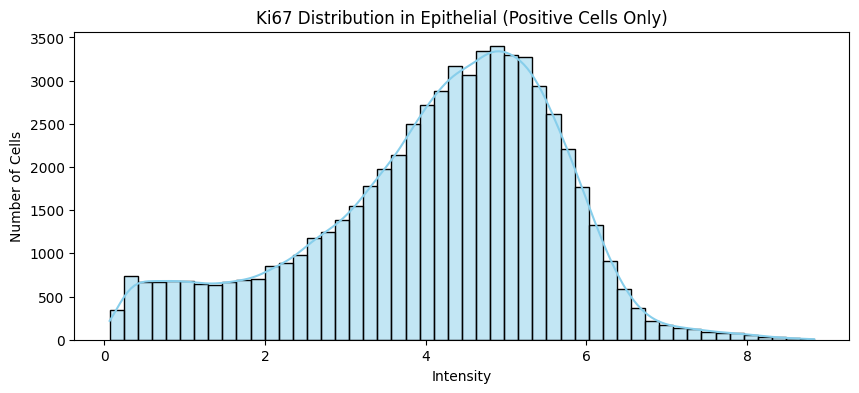

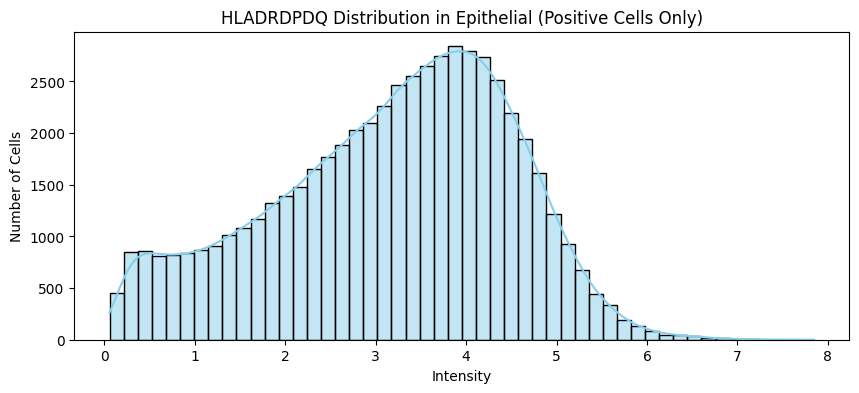

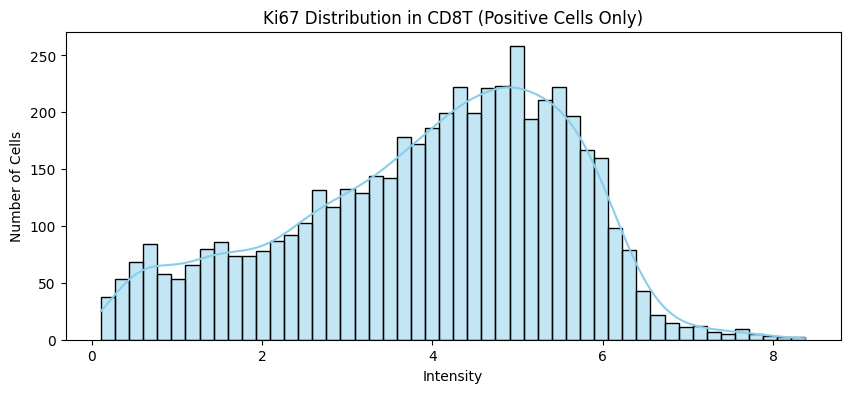

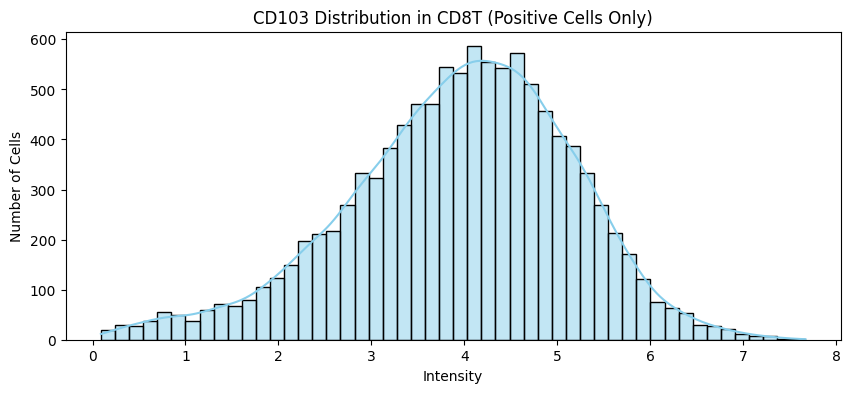

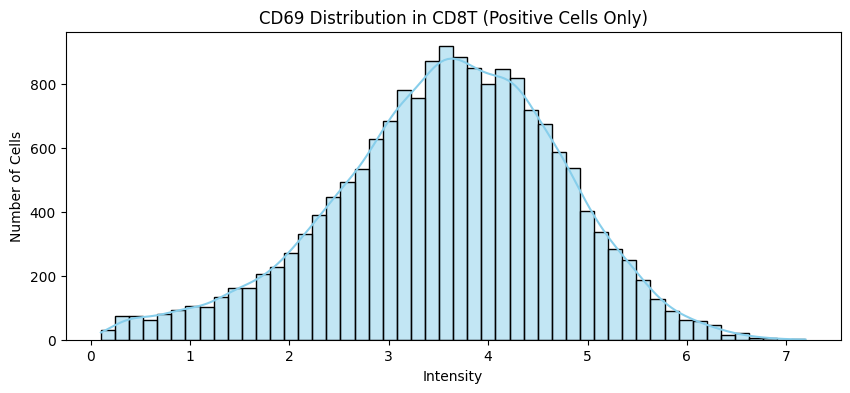

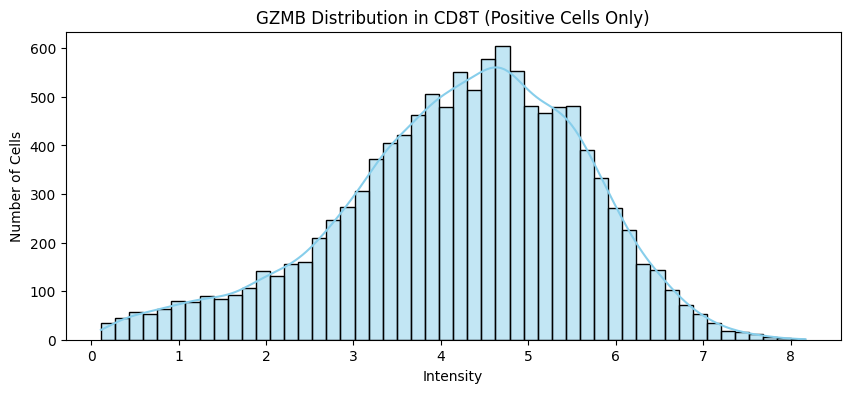

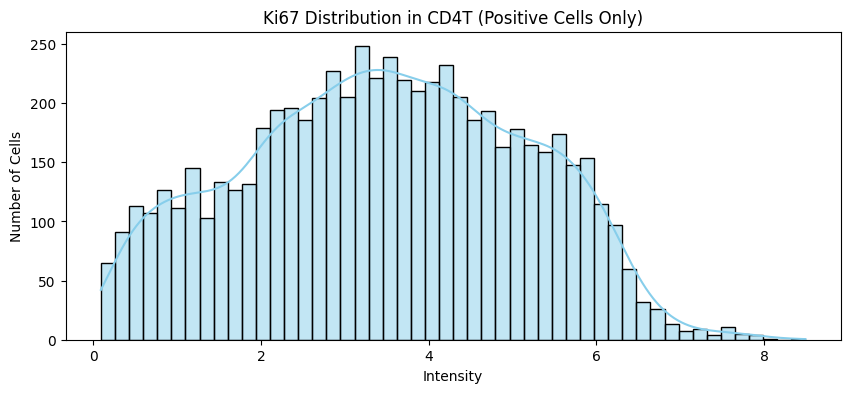

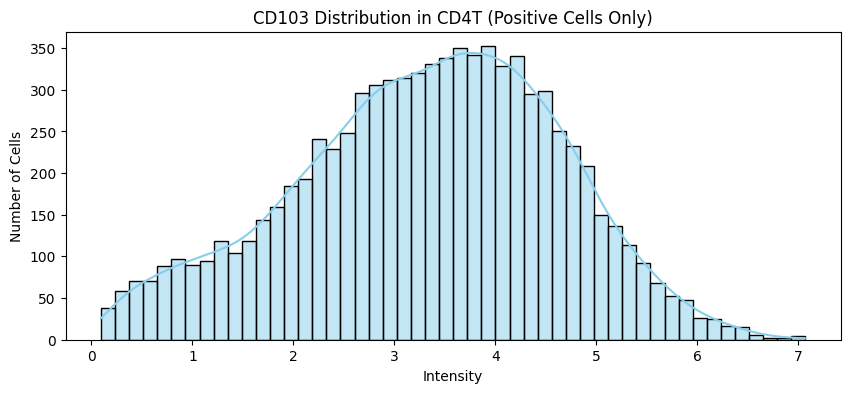

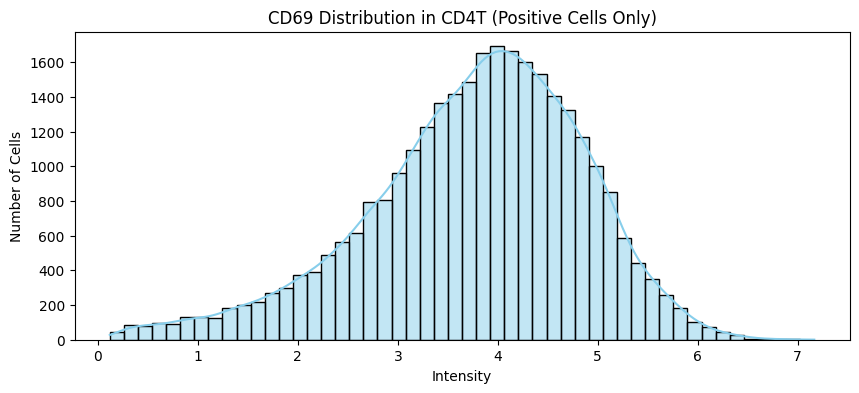

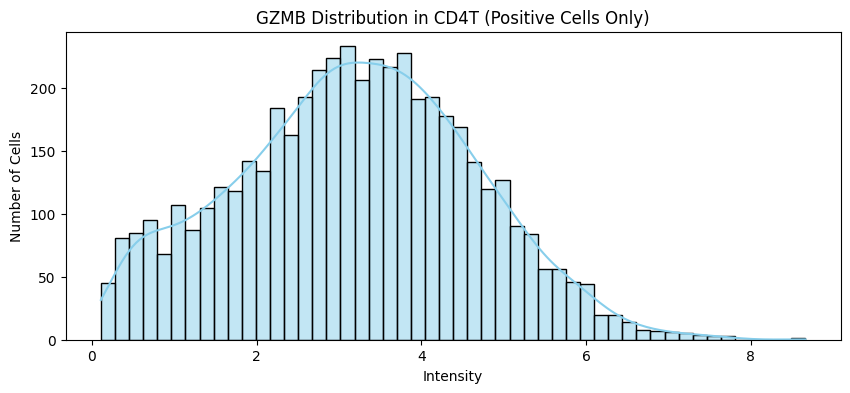

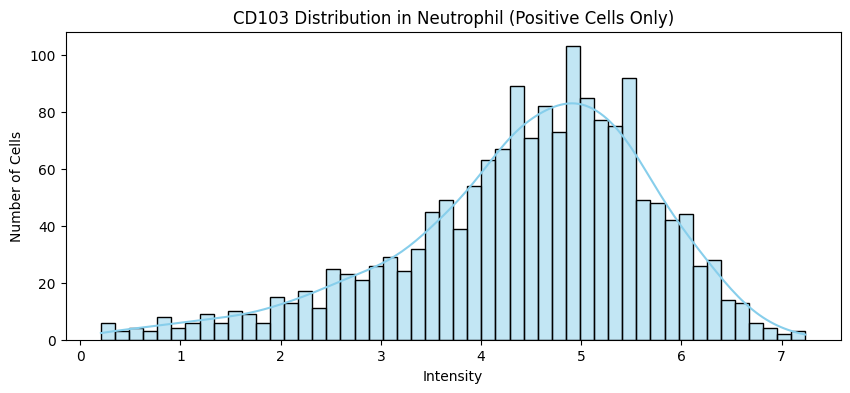

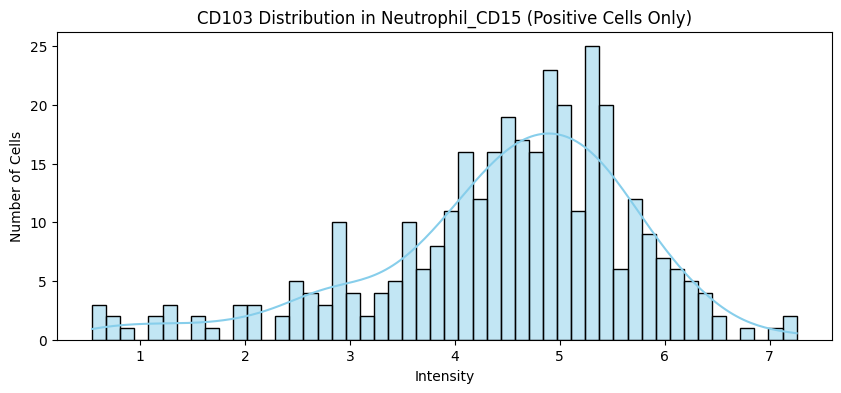

In [10]:
for fig in figs:
    display(fig)